In [5]:
import numpy as np
import matplotlib.pyplot as plt

TD_learning

# if learning rate is not constant

In [6]:
def learning_rate_fn(trajectory, state):
    visits = trajectory.count(state)
    return 1 / (visits+1)

In [8]:
def TD_update(V, S, R_next, S_next, discounted_factor, alpha):
    V_new = V[S] + alpha*(R_next+discounted_factor*V[S_next] - V[S])  #if S is at time t
    return V_new

def TD_algorithm(P, R, discounted_factor, learning_rate_fn, Max_iteration = 10000):

    iteration = 0
    current_state = 0

    #-----------------------------------------------------------------------------------------
    Trajectory_of_S = [current_state]
    Trajectory_of_R = {0:[],1:[],2:[]}
    V_history = {0:[],1:[],2:[]}
    V = np.zeros(len(P), dtype = float) #[0, 0, 0]
    #-----------------------------------------------------------------------------------------
    
    while iteration < Max_iteration:
        iteration += 1

        #執行演算法--------------------------------------------------------------------------------------
        S_next = np.random.choice(len(P), p = P[current_state]) #抽樣s'
        R_next = R[current_state][S_next] #抽樣 r when s to s'
        alpha = learning_rate_fn(Trajectory_of_S, current_state)
        V_new = TD_update(V, current_state, R_next, S_next, discounted_factor, alpha) #更新V
        V[current_state] = V_new #存入V(s)
        #--------------------------------------------------------------------------------------

        Trajectory_of_S.append(S_next)
        Trajectory_of_R[current_state].append(R_next)
        V_history[current_state].append(V_new)

        current_state = S_next #更新目前狀態
    return V, Trajectory_of_S, Trajectory_of_R, V_history

# if learning rate is constant

In [7]:
def TD_update_lsc(V, S, R_next, S_next, discounted_factor, alpha):
    V_new = V[S] + alpha*(R_next+discounted_factor*V[S_next] - V[S])  #if S is at time t
    return V_new

def TD_algorithm_lsc(P, R, discounted_factor, alpha, Max_iteration = 10000):

    iteration = 0
    current_state = 0

    #-----------------------------------------------------------------------------------------
    Trajectory_of_S = [current_state]
    Trajectory_of_R = {0:[],1:[],2:[]}
    V_history = {0:[],1:[],2:[]}
    V = np.zeros(len(P), dtype = float) #[0, 0, 0]
    #-----------------------------------------------------------------------------------------
    
    while iteration < Max_iteration:
        iteration += 1

        #執行演算法--------------------------------------------------------------------------------------
        S_next = np.random.choice(len(P), p = P[current_state]) #抽樣s'
        R_next = R[current_state][S_next] #抽樣 r when s to s'
        V_new = TD_update_lsc(V, current_state, R_next, S_next, discounted_factor, alpha) #更新V
        V[current_state] = V_new #存入V(s)
        #--------------------------------------------------------------------------------------

        Trajectory_of_S.append(S_next)
        Trajectory_of_R[current_state].append(R_next)
        V_history[current_state].append(V_new)

        current_state = S_next #更新目前狀態
    return V, Trajectory_of_S, Trajectory_of_R, V_history

## Test_1 : P and R are deterministic

closed form of MRP

In [28]:
I =np.eye(3) #造一個n*n的identity matrix

P = np.array([
    [0,1,0],
    [0,0,1],
    [1,0,0]
    ])

discounted_factor = 0.333

R = np.array([10,0,5])
V_True = np.linalg.inv( I - discounted_factor * P) @ R 
V_True

array([10.95912194,  2.88024607,  8.64938761])

In [35]:
P = [[0,1,0],
     [0,0,1],
     [1,0,0]]

R = [[0,10,0],
     [0,0,0],
     [5,0,0]]

discounted_factor = 0.333

np.random.seed(42)
#V, Trajectory_of_S, Trajectory_of_R, V_history = TD_algorithm(P, R, discounted_factor, learning_rate_fn = learning_rate_fn, Max_iteration= 10000)
V_lsc, Trajectory_of_S_lsc, Trajectory_of_R_lsc, V_history_lsc = TD_algorithm_lsc(P, R, discounted_factor, alpha = 0.05, Max_iteration= 10000)
V_lsc
#print(f"state 0 value {V_history_lsc[0][0:3]}")
#print(f"state 1 value {V_history_lsc[1][0:3]}")
#print(f"state 2 value {V_history_lsc[2][0:3]}")

array([10.95912194,  2.88024607,  8.64938761])

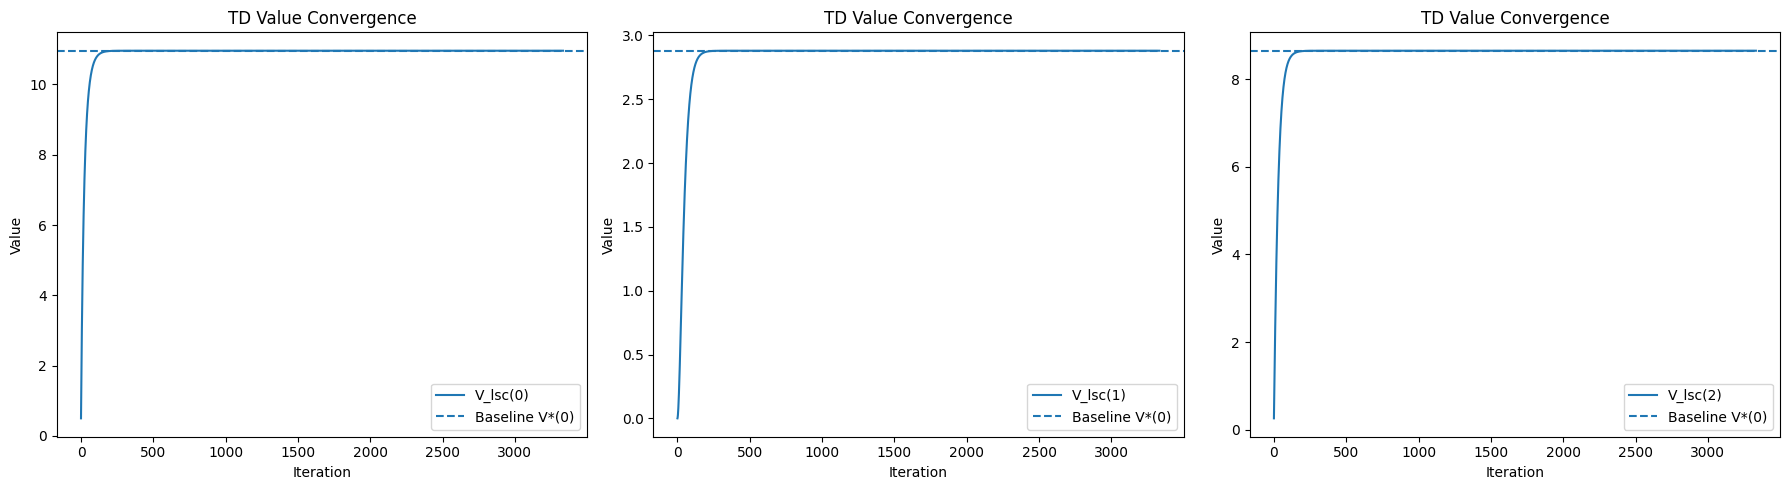

In [36]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(V_history_lsc[0], label="V_lsc(0)")
#plt.plot(V_history[0], label="V(0)")
plt.axhline(y=V_True[0], linestyle="--", label="Baseline V*(0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence")
plt.legend()

plt.subplot(1,3,2)
plt.plot(V_history_lsc[1], label="V_lsc(1)")
#plt.plot(V_history[1], label="V(1)")
plt.axhline(y=V_True[1], linestyle="--", label="Baseline V*(0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence")
plt.legend()

plt.subplot(1,3,3)
plt.plot(V_history_lsc[2], label="V_lsc(2)")
#plt.plot(V_history[2], label="V(2)")
plt.axhline(y=V_True[2], linestyle="--", label="Baseline V*(0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence")
plt.legend()

plt.tight_layout()
plt.show()


## Test 2 : P is stochastic , R is deterministic

In [ ]:
I =np.eye(3) 

P = np.array([
    [0,0.5,0.5],
    [0.5,0,0.5],
    [0.5,0.5,0]])

R = np.array([
    [0,10,0],
    [0,0,9],
    [8,0,0]])

R_bar = P*R
R_total = np.array([np.sum(R_bar[0]), np.sum(R_bar[1]), np.sum(R_bar[2])])
V_True = np.linalg.inv( I - discounted_factor * P) @ R_total 
V_True

array([45.34482759, 45.        , 44.65517241])

In [183]:
P = [
    [0,0.5,0.5],
    [0.5,0,0.5],
    [0.5,0.5,0]]

R = [
    [0,10,0],
    [0,0,9],
    [8,0,0]]

discounted_factor = 0.9

np.random.seed(42)

#V, Trajectory_of_S, Trajectory_of_R, V_history = TD_algorithm(P, R, discounted_factor, learning_rate_fn = learning_rate_fn, Max_iteration= 10000)
V_lsc, Trajectory_of_S_lsc, Trajectory_of_R_lsc, V_history_lsc = TD_algorithm_lsc(P, R, discounted_factor, alpha = 0.2 , Max_iteration= 10000)
V_lsc

array([47.0761235 , 46.87381873, 47.07135495])

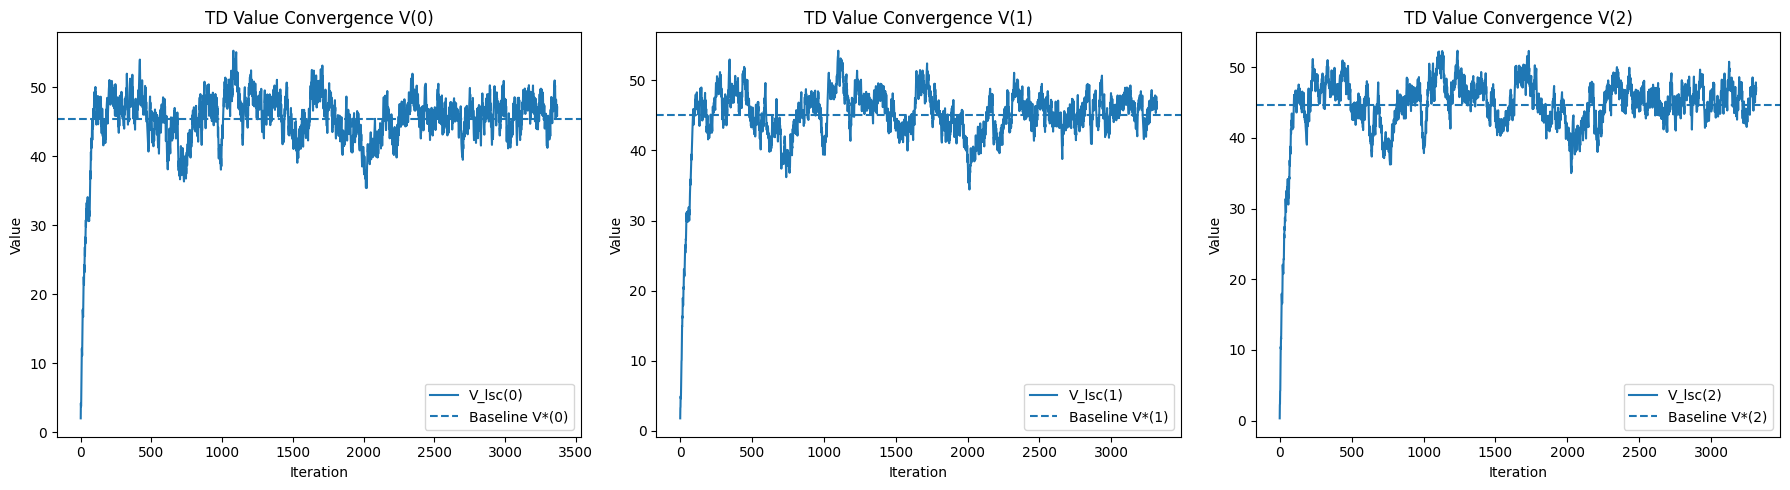

In [184]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(V_history_lsc[0], label="V_lsc(0)")
#plt.plot(V_history[0], label="V(0)")
plt.axhline(y=V_True[0], linestyle="--", label="Baseline V*(0)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(0)")
plt.legend()

plt.subplot(1,3,2)
plt.plot(V_history_lsc[1], label="V_lsc(1)")
#plt.plot(V_history[1], label="V(1)")
plt.axhline(y=V_True[1], linestyle="--", label="Baseline V*(1)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(1)")
plt.legend()

plt.subplot(1,3,3)
plt.plot(V_history_lsc[2], label="V_lsc(2)")
#plt.plot(V_history[2], label="V(2)")
plt.axhline(y=V_True[2], linestyle="--", label="Baseline V*(2)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(2)")
plt.legend()

plt.tight_layout()
plt.show()

## Test 3 : P and R are stochastic

In [208]:
def TD_update_lsc(V, S, R_next, S_next, discounted_factor, alpha):
    V_new = V[S] + alpha*(R_next+discounted_factor*V[S_next] - V[S])  #if S is at time t
    return V_new

def TD_algorithm_slsc(P, R, discounted_factor, alpha, Max_iteration = 10000):

    iteration = 0
    current_state = 0

    #-----------------------------------------------------------------------------------------
    Trajectory_of_S = [current_state]
    Trajectory_of_R = {0:[],1:[],2:[]}
    V_history = {0:[],1:[],2:[]}
    V = np.zeros(len(P), dtype = float) #[0, 0, 0]
    #-----------------------------------------------------------------------------------------
    
    while iteration < Max_iteration:
        iteration += 1

        #執行演算法--------------------------------------------------------------------------------------
        S_next = np.random.choice(len(P), p = P[current_state]) #抽樣s'
        R_mean = R[current_state][S_next] #抽樣 r when s to s'
        R_next = np.random.normal(R_mean, scale = 10)
        V_new = TD_update_lsc(V, current_state, R_next, S_next, discounted_factor, alpha) #更新V
        V[current_state] = V_new #存入V(s)
        #--------------------------------------------------------------------------------------

        Trajectory_of_S.append(S_next)
        Trajectory_of_R[current_state].append(R_next)
        V_history[current_state].append(V_new)

        current_state = S_next #更新目前狀態
    return V, Trajectory_of_S, Trajectory_of_R, V_history

In [209]:
I =np.eye(3) #造一個n*n的identity matrix

P = np.array([
    [0,0.5,0.5],
    [0.5,0,0.5],
    [0.5,0.5,0]])

R = np.array([
    [0,10,0],
    [0,0,9],
    [8,0,0]])

R_bar = P*R
R_total = np.array([np.sum(R_bar[0]), np.sum(R_bar[1]), np.sum(R_bar[2])])
V_True = np.linalg.inv( I - discounted_factor * P) @ R_total 
V_True

array([45.34482759, 45.        , 44.65517241])

In [213]:
P = [
    [0,0.5,0.5],
    [0.5,0,0.5],
    [0.5,0.5,0]]

R = [
    [0,10,0],
    [0,0,9],
    [8,0,0]]

discounted_factor = 0.9

np.random.seed(42)

#V, Trajectory_of_S, Trajectory_of_R, V_history = TD_algorithm(P, R, discounted_factor, learning_rate_fn = learning_rate_fn, Max_iteration= 10000)
V_slsc, Trajectory_of_S_slsc, Trajectory_of_R_slsc, V_history_slsc = TD_algorithm_slsc(P, R, discounted_factor, alpha = 0.2 , Max_iteration= 10000)
V_slsc


array([41.77064466, 52.23921382, 54.49241172])

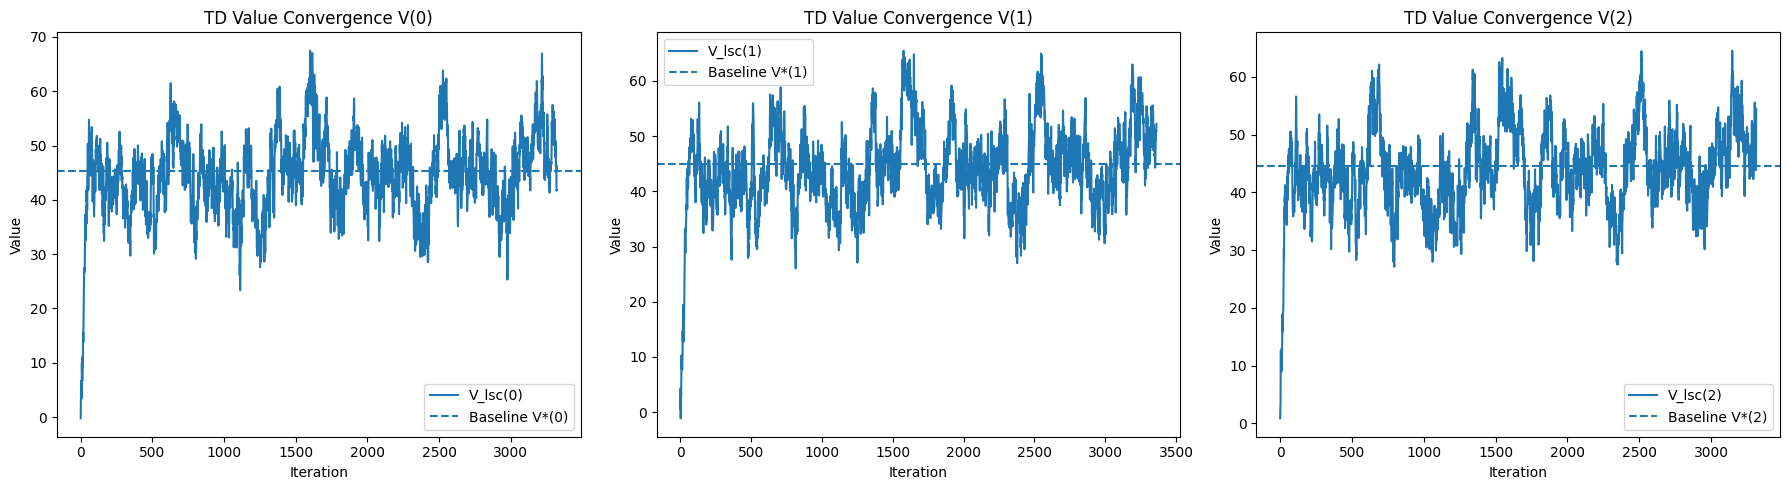

In [214]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(V_history_slsc[0], label="V_lsc(0)")
#plt.plot(V_history[0], label="V(0)")
plt.axhline(y=V_True[0], linestyle="--", label="Baseline V*(0)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(0)")
plt.legend()

plt.subplot(1,3,2)
plt.plot(V_history_slsc[1], label="V_lsc(1)")
#plt.plot(V_history[1], label="V(1)")
plt.axhline(y=V_True[1], linestyle="--", label="Baseline V*(1)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(1)")
plt.legend()

plt.subplot(1,3,3)
plt.plot(V_history_slsc[2], label="V_lsc(2)")
#plt.plot(V_history[2], label="V(2)")
plt.axhline(y=V_True[2], linestyle="--", label="Baseline V*(2)")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("TD Value Convergence V(2)")
plt.legend()

plt.tight_layout()
plt.show()